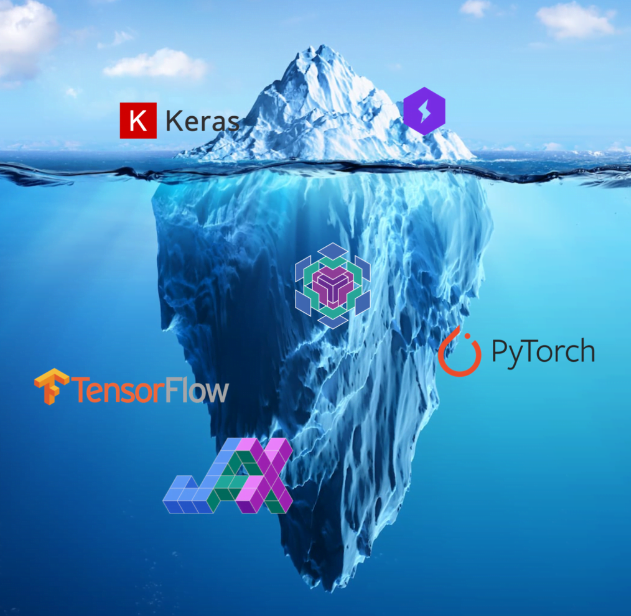

# **1.1. Однослойный перцептрон с сигмоидной активацией**
*Простое прямое распространение через один слой нейронов с сигмоидной функцией активации.*

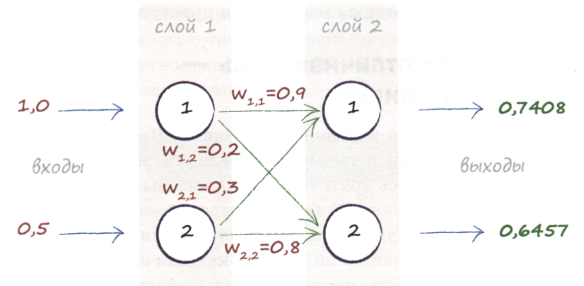

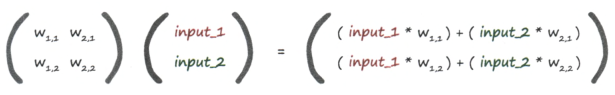

In [1]:
import numpy as np
sigmoid = lambda x: 1/(1+np.power(np.e, -x))
x1 = 1.0
x2 = 0.5
w11 = 0.9
w12 = 0.2
w21 = 0.3
w22 = 0.8
w = np.array([[w11, w21],[w12, w22]])
i = np.array([x1, x2])
sigmoid(w@i)

array([0.7407749 , 0.64565631])

In [2]:
import torch
w = torch.tensor(w)
i = torch.tensor(i)
# code 1.1
torch.nn.functional.sigmoid(w@i)

tensor([0.7408, 0.6457], dtype=torch.float64)



```
tensor([0.7408, 0.6457])
```



https://pytorch.org/docs/stable/generated/torch.sigmoid.html

In [3]:
w = np.array([[w11, w21],[w12, w22]])
i = np.array([x1, x2])

In [4]:
import tensorflow as tf
i = tf.constant([x1, x2], shape=(2, 1), dtype="float64") # или [[x1], [x2]] - вектор-столбец 2×1
w = tf.constant(w)
#i = tf.constant(i)

# code 1.2
tf.math.sigmoid(w@i)

2025-03-28 09:48:23.250969: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743144503.277324  742311 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743144503.285643  742311 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743144503.308461  742311 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743144503.308514  742311 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743144503.308520  742311 computation_placer.cc:177] computation placer alr

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[0.7407749 ],
       [0.64565631]])>



```
<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.74077487],
       [0.64565635]], dtype=float32)>
```



https://www.tensorflow.org/api_docs/python/tf/math/sigmoid

In [5]:
import jax
import jax.numpy as jnp
i = jnp.array([x1, x2]).reshape(-1, 1)
w = jnp.array(w)
# code 1.3
jax.nn.sigmoid(w@i)

Array([[0.74077487],
       [0.6456563 ]], dtype=float32)



```
Array([[0.74077487],
       [0.6456563 ]], dtype=float32)
```



https://docs.jax.dev/en/latest/_autosummary/jax.nn.sigmoid.html

---

# **1.2. Двухслойная нейронная сеть с сигмоидой**
*Каскад из двух полносвязных слоёв с поэлементной сигмоидной активацией после каждого.*

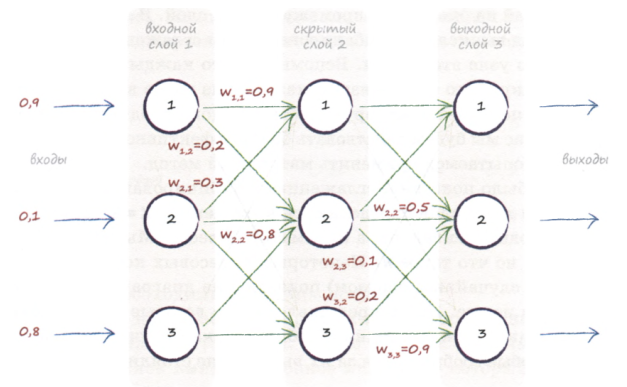

In [6]:
w1 = np.array([[0.9, 0.3, 0.4],[0.2, 0.8, 0.2],[0.1, 0.5, 0.6]])
w2 = np.array([[0.3, 0.7, 0.5],[0.6, 0.5, 0.2],[0.8, 0.1, 0.9]])
i = np.array([0.9, 0.1, 0.8])
sigmoid(w2@sigmoid(w1@i))

array([0.72630335, 0.70859807, 0.77809706])

In [7]:
import torch

w1 = torch.tensor(w1)
w2 = torch.tensor(w2)
i = torch.tensor(i)
# code 2.1
torch.nn.functional.sigmoid(w2@sigmoid(w1@i))

tensor([0.7263, 0.7086, 0.7781], dtype=torch.float64)



```
tensor([0.7263, 0.7086, 0.7781])
```



In [32]:
w1 = np.array([[0.9, 0.3, 0.4],[0.2, 0.8, 0.2],[0.1, 0.5, 0.6]])
w2 = np.array([[0.3, 0.7, 0.5],[0.6, 0.5, 0.2],[0.8, 0.1, 0.9]])
i = np.array([0.9, 0.1, 0.8])

In [33]:
import tensorflow as tf

# code 2.2
w1 = tf.constant(w1)
w2 = tf.constant(w2)
i = tf.constant(i.reshape(-1, 1))

tf.math.sigmoid(w2@tf.math.sigmoid(w1@i))

<tf.Tensor: shape=(3, 1), dtype=float64, numpy=
array([[0.72630335],
       [0.70859807],
       [0.77809706]])>



```
<tf.Tensor: shape=(3, 1), dtype=float32, numpy=
array([[0.72630334],
       [0.7085981 ],
       [0.7780971 ]], dtype=float32)>
```



In [26]:
w1 = np.array([[0.9, 0.3, 0.4],[0.2, 0.8, 0.2],[0.1, 0.5, 0.6]])
w2 = np.array([[0.3, 0.7, 0.5],[0.6, 0.5, 0.2],[0.8, 0.1, 0.9]])
i = np.array([0.9, 0.1, 0.8])

In [27]:
import jax

# code 2.3
i = jnp.array(i)
w1 = jnp.array(w1)
w2 = jnp.array(w2)
# code 1.3
jax.nn.sigmoid(w2@jax.nn.sigmoid(w1@i))

Array([0.7263034 , 0.7085981 , 0.77809703], dtype=float32)



```
Array([[0.7263034 ],
       [0.7085981 ],
       [0.77809703]], dtype=float32)
```



---

# **1.3. Транспонирование матрицы весов и умножение на ошибку**
*Операция обратного распространения: вычисление градиента для предыдущего слоя через транспонированную матрицу весов.*

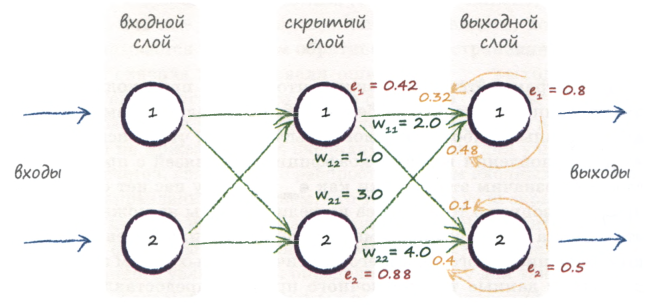

In [28]:
w11 = 2.0
w12 = 1.0
w21 = 3.0
w22 = 4.0
e1 = 0.8
e2 = 0.5
w = np.array([[w11, w21],[w12, w22]])
e = np.array([e1, e2])
w.T@e

array([2.1, 4.4])

In [29]:
import torch

w = torch.tensor(w)
e = torch.tensor(e)
# code 3.1
w.T@e

tensor([2.1000, 4.4000], dtype=torch.float64)



```
tensor([2.1000, 4.4000])
```



In [30]:
w = np.array([[w11, w21],[w12, w22]])
e = np.array([e1, e2])

In [31]:
import tensorflow as tf

w = tf.constant(w.T)
e = tf.constant(e.reshape(-1, 1))
# code 3.2
w@e

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[2.1],
       [4.4]])>



```
<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.1],
       [4.4]], dtype=float32)>
```



https://www.tensorflow.org/api_docs/python/tf/transpose

In [36]:
w = np.array([[w11, w21],[w12, w22]])
e = np.array([e1, e2])

In [37]:
import jax

w = jnp.array(w)
e = jnp.array(e)
# code 3.3
w.T@e

Array([2.1, 4.4], dtype=float32)



```
Array([[2.1],
       [4.4]], dtype=float32)
```



---

# **1.4. Обновление весов по правилу градиентного спуска**
*Коррекция весов на основе ошибки, производной сигмоиды и выходов нейронов (упрощённый backpropagation).*

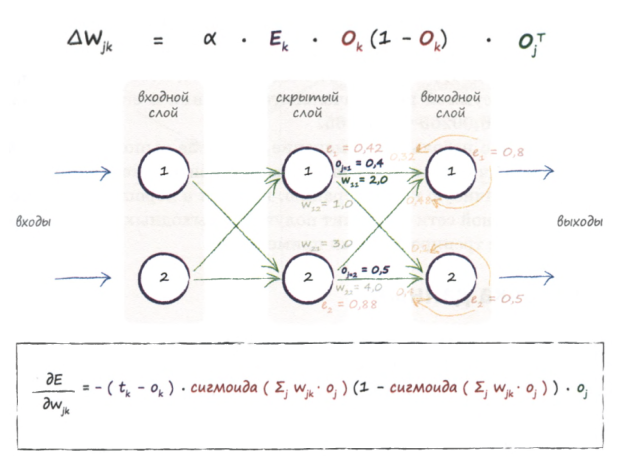

$$
\sigma(x) = \frac{1}{1 + e^{-2,3}} \approx 0,909
$$
$$
\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x)) = 0,909 \cdot (1 - 0,909) \approx 0,083.
$$
$$
\Delta w_{11} = -\mathbf{e}_1 \cdot \sigma'(x) \cdot \mathbf{o}_j = -0,8 \cdot 0,083 \cdot 0,4 \approx -0,0265.
$$
$$
\Delta w_{11} = \eta \cdot (-0,0265) = 0,1 \cdot (-0,0265) = -0,00265.
$$
$$
w_{11} = w_{11} - \Delta w_{11} = 2,0 + 0,00265 = 2,00265.
$$

In [38]:
o1 = 0.4
o2 = 0.5
w11 = 2.0
w12 = 1.0
w21 = 3.0
w22 = 4.0
e1 = 0.8
e2 = 0.5
w = np.array([[w11, w21],[w12, w22]])
o = np.array([o1, o2])
e = np.array([e1, e2])
w + 0.1*e*sigmoid(w@o)*(1-sigmoid(w@o))*o

array([[2.00265023, 3.00190637],
       [1.00265023, 4.00190637]])

In [39]:
import torch

w = torch.tensor(w)
o = torch.tensor(o)
e = torch.tensor(e)
# code 4.1
w + 0.1*e*torch.nn.functional.sigmoid(w@o)*(1 - torch.nn.functional.sigmoid(w@o))*o

tensor([[2.0027, 3.0019],
        [1.0027, 4.0019]], dtype=torch.float64)



```
tensor([[2.0027, 3.0019],
        [1.0027, 4.0019]])
```



In [40]:
w = np.array([[w11, w21],[w12, w22]])
o = np.array([o1, o2])
e = np.array([e1, e2])

In [41]:
import tensorflow as tf

w = tf.constant(w)
o = tf.constant(o.reshape(-1, 1))
e = tf.constant(e.reshape(-1, 1))

# code 4.2
w + 0.1*e*tf.math.sigmoid(w@o)*(1 - tf.math.sigmoid(w@o))*o

<tf.Tensor: shape=(2, 2), dtype=float64, numpy=
array([[2.00265023, 3.00265023],
       [1.00190637, 4.00190637]])>



```
<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2.0026503, 3.0026503],
       [1.0019064, 4.0019064]], dtype=float32)>
```



In [42]:
w = np.array([[w11, w21],[w12, w22]])
o = np.array([o1, o2])
e = np.array([e1, e2])

In [43]:
import jax

w = jnp.array(w)
o = jnp.array(o)
e = jnp.array(e)
# code 4.3
w + 0.1*e*jax.nn.sigmoid(w@o)*(1 - jax.nn.sigmoid(w@o))*o

Array([[2.0026503, 3.0019064],
       [1.0026503, 4.0019064]], dtype=float32)



```
Array([[2.0026503, 3.0026503],
       [1.0019064, 4.0019064]], dtype=float32)
```



---

# **2.1. Однослойный перцептрон с сигмоидной активацией**

In [18]:
import torch

x1 = 1.0
x2 = 0.5
w11 = 0.9
w12 = 0.2
w21 = 0.3
w22 = 0.8

linear_layer = torch.nn.Linear(2, 2, bias=False) # Создаем слой Linear
linear_layer.weight.data = torch.tensor([[w11, w21], [w12, w22]])
sigmoid = torch.nn.Sigmoid() # Создаем функцию активации
i = torch.tensor([x1, x2]) # Входные данные
sigmoid(linear_layer(i)) # Прямой проход

tensor([0.7408, 0.6457], grad_fn=<SigmoidBackward0>)

In [19]:
import tensorflow as tf

# Создаем плотный слой с ручной инициализацией весов
dense = tf.keras.layers.Dense(2, use_bias=False, activation='sigmoid')
dense.build(input_shape=(None, 2)) # Инициализируем слой
dense.kernel.assign([[w11, w21], [w12, w22]]) # Устанавливаем веса
i = tf.constant([[x1, x2]]) # Входные данные
dense(i) # Прямой проход

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[0.7310586, 0.6681878]], dtype=float32)>

In [20]:
import jax
import jax.numpy as jnp
from jax.example_libraries import stax

w = jnp.array([[w11,w21],[w12,w22]])
init_fun, apply_fun = stax.serial(
    stax.Dense(2, W_init=lambda *_: w),
    stax.elementwise(jax.nn.sigmoid)
)
_, params = init_fun(jax.random.PRNGKey(0), input_shape=(-1, 2))
i = jnp.array([x1, x2])
apply_fun(params, i)

Array([0.7284245, 0.6674056], dtype=float32)

---

# **2.2. Двухслойная нейронная сеть с сигмоидой**

In [67]:
import torch

w1 = torch.tensor([[0.9, 0.3, 0.4],[0.2, 0.8, 0.2],[0.1, 0.5, 0.6]])
w2 = torch.tensor([[0.3, 0.7, 0.5],[0.6, 0.5, 0.2],[0.8, 0.1, 0.9]])
i = torch.tensor([0.9, 0.1, 0.8])

# code 5.1
linear1 = torch.nn.Linear(3, 3, bias=False)
linear1.weight.data = torch.tensor(w1)
linear2 = torch.nn.Linear(3, 3, bias=False)
linear2.weight.data = torch.tensor(w2)

act = torch.nn.Sigmoid()
act(linear2(act(linear1(i))))

/tmp/ipykernel_742311/2306018653.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  linear1.weight.data = torch.tensor(w1)
/tmp/ipykernel_742311/2306018653.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  linear2.weight.data = torch.tensor(w2)


tensor([0.7263, 0.7086, 0.7781], grad_fn=<SigmoidBackward0>)



```
tensor([0.7263, 0.7086, 0.7781], grad_fn=<SigmoidBackward0>)
```



In [68]:
import tensorflow as tf

w1 = tf.constant([[0.9, 0.3, 0.4],[0.2, 0.8, 0.2],[0.1, 0.5, 0.6]])
w2 = tf.constant([[0.3, 0.7, 0.5],[0.6, 0.5, 0.2],[0.8, 0.1, 0.9]])
i = tf.constant([0.9, 0.1, 0.8], shape=(1, 3))

# code 5.2

dense1 = tf.keras.layers.Dense(3, use_bias=False, activation='sigmoid')
dense1.build(input_shape=(None, 3))
dense1.kernel.assign(w1)

dense2 = tf.keras.layers.Dense(3, use_bias=False, activation='sigmoid')
dense2.build(input_shape=(None, 3))
dense2.kernel.assign(w2)

dense2(dense1(i)) # Прямой проход

<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[0.7655829 , 0.7127864 , 0.75486505]], dtype=float32)>



```
<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[0.7655829 , 0.7127864 , 0.75486505]], dtype=float32)>
```



In [52]:
import jax
import jax.numpy as jnp
from jax.example_libraries import stax

w1 = jnp.array([[0.9, 0.3, 0.4],[0.2, 0.8, 0.2],[0.1, 0.5, 0.6]])
w2 = jnp.array([[0.3, 0.7, 0.5],[0.6, 0.5, 0.2],[0.8, 0.1, 0.9]])
i = jnp.array([0.9, 0.1, 0.8])

# code 5.3
init_fun, apply_fun = stax.serial(
    stax.Dense(3, W_init=lambda *_: w1),
    stax.elementwise(jax.nn.sigmoid),
    stax.Dense(3, W_init=lambda *_: w2),
    stax.elementwise(jax.nn.sigmoid)
)
_, params = init_fun(jax.random.PRNGKey(0), input_shape=(-1, 3))
apply_fun(params, i)

Array([0.7653368 , 0.70776206, 0.7568342 ], dtype=float32)



```
Array([0.7653368 , 0.70776206, 0.7568342 ], dtype=float32)
```



---

# **3.1. Однослойный перцептрон с сигмоидной активацией**

In [53]:
import torch
import torch.nn as nn
import numpy as np

x1 = 1.0
x2 = 0.5
w11 = 0.9
w12 = 0.2
w21 = 0.3
w22 = 0.8

# Определяем модель как класс, наследуемый от nn.Module
class Net(nn.Module):
    def __init__(self, weights):
        super().__init__()
        # Плотный слой с предопределенными весами
        self.fc = nn.Linear(2, 2, bias=False)  # 2 входа, 2 выхода, без смещения
        # Задаем веса
        self.fc.weight.data = torch.from_numpy(weights).float()  # Преобразуем numpy массив в torch тензор

    def forward(self, x):
        # Плотный слой
        x = self.fc(x)
        # Активация sigmoid
        x = torch.sigmoid(x)
        return x

# Задаем веса
w = np.array([[w11,w21],[w12,w22]])

# Создаем экземпляр модели
model = Net(weights=w)

# Входные данные
i = torch.tensor([x1, x2], dtype=torch.float32) # Создаем тензор PyTorch и указываем тип данных
i = i.unsqueeze(0) # Добавляем измерение batch, теперь форма (1, 2)

# Применяем модель
output = model(i)
output

tensor([[0.7408, 0.6457]], grad_fn=<SigmoidBackward0>)

In [25]:
import tensorflow as tf
import numpy as np

x1 = 1.0
x2 = 0.5
w11 = 0.9
w12 = 0.2
w21 = 0.3
w22 = 0.8

# Определяем модель как класс, наследуемый от tf.keras.Model
class Net(tf.keras.Model):
    def __init__(self, weights):
        super(Net, self).__init__()
        # Создаем слой Dense с предопределенными весами
        self.dense = tf.keras.layers.Dense(
            units=2,
            use_bias=False,
            kernel_initializer=tf.constant_initializer(weights),
            activation='sigmoid'
        )

    def call(self, inputs):
        return self.dense(inputs)

# Задаем веса
w = np.array([[w11, w21], [w12, w22]])

# Создаем экземпляр модели
model = Net(weights=w)

# Входные данные (добавляем размерность батча)
i = tf.constant([[x1, x2]], dtype=tf.float32)

# Применяем модель
output = model(i)

# Выводим результат
output

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[0.7310586, 0.6681878]], dtype=float32)>

In [54]:
import jax
import jax.numpy as jnp
from flax import linen as nn

x1 = 1.0
x2 = 0.5
w11 = 0.9
w12 = 0.2
w21 = 0.3
w22 = 0.8

# Определяем модель как класс, наследуемый от nn.Module
class Net(nn.Module):
    weights: jnp.ndarray

    @nn.compact
    def __call__(self, x):
        # Плотный слой с предопределенными весами
        x = nn.Dense(features=2, use_bias=False,
                    kernel_init=lambda *_: self.weights)(x)
        # Активация sigmoid
        x = jax.nn.sigmoid(x)
        return x

# Задаем веса
w = jnp.array([[w11,w21],[w12,w22]])

# Создаем экземпляр модели
model = Net(weights=w)

# Инициализируем параметры
params = model.init(jax.random.PRNGKey(0), jnp.ones((1, 2)))

# Входные данные
i = jnp.array([x1, x2])

# Применяем модель
output = model.apply(params, i)
output

Array([0.7310586, 0.6681878], dtype=float32)

---

# **3.2. Двухслойная нейронная сеть с сигмоидой**

In [59]:
import torch
import torch.nn as nn
import numpy as np

w1 = np.array([[0.9, 0.3, 0.4],[0.2, 0.8, 0.2],[0.1, 0.5, 0.6]])
w2 = np.array([[0.3, 0.7, 0.5],[0.6, 0.5, 0.2],[0.8, 0.1, 0.9]])
i = torch.tensor([0.9, 0.1, 0.8])

# code 6.1

class Net(nn.Module):
    def __init__(self, weights):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 3, bias=False),
            nn.Sigmoid(),
            nn.Linear(3, 3, bias=False),
            nn.Sigmoid()
        )
        for i in range(len(weights)):
            self.network[2*i].weight.data = torch.from_numpy(weights[i]).float()


    def forward(self, x):
        # Плотный слой
        return self.network(x)

model = Net(weights=(w1, w2))

#i = i.unsqueeze(0)

# Применяем модель
output = model(i)
output

tensor([0.7263, 0.7086, 0.7781], grad_fn=<SigmoidBackward0>)



```
tensor([[0.7263, 0.7086, 0.7781]], grad_fn=<SigmoidBackward0>)
```



In [60]:
import tensorflow as tf
import numpy as np

w1 = np.array([[0.9, 0.3, 0.4],[0.2, 0.8, 0.2],[0.1, 0.5, 0.6]])
w2 = np.array([[0.3, 0.7, 0.5],[0.6, 0.5, 0.2],[0.8, 0.1, 0.9]])
i = tf.constant([0.9, 0.1, 0.8], shape=(1, 3))

# code 6.2

# Определяем модель как класс, наследуемый от tf.keras.Model
class Net(tf.keras.Model):
    def __init__(self, weights):
        super(Net, self).__init__()
        # Создаем слой Dense с предопределенными весами
        self.dense1 = tf.keras.layers.Dense(
            units=3,
            use_bias=False,
            kernel_initializer=tf.constant_initializer(weights[0]),
            activation='sigmoid'
        )
        self.dense2 = tf.keras.layers.Dense(
            units=3,
            use_bias=False,
            kernel_initializer=tf.constant_initializer(weights[1]),
            activation='sigmoid'
        )

    def call(self, inputs):
        return self.dense2(self.dense1(inputs))

# Создаем экземпляр модели
model = Net(weights=(w1, w2))

# Применяем модель
output = model(i)

# Выводим результат
output

<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[0.7655829 , 0.7127864 , 0.75486505]], dtype=float32)>



```
tf.Tensor([[0.7655829  0.7127864  0.75486505]], shape=(1, 3), dtype=float32)
```



In [65]:
import jax
import jax.numpy as jnp
from flax import linen as nn

w1 = jnp.array([[0.9, 0.3, 0.4],[0.2, 0.8, 0.2],[0.1, 0.5, 0.6]])
w2 = jnp.array([[0.3, 0.7, 0.5],[0.6, 0.5, 0.2],[0.8, 0.1, 0.9]])
i = jnp.array([0.9, 0.1, 0.8])

# code 6.3

# Определяем модель как класс, наследуемый от nn.Module
class Net(nn.Module):
    weights: tuple

    @nn.compact
    def __call__(self, x):
        # Плотный слой с предопределенными весами
        x = nn.Dense(features=3, use_bias=False,
                    kernel_init=lambda *_: self.weights[0])(x)
        # Активация sigmoid
        x = jax.nn.sigmoid(x)
        x = nn.Dense(features=3, use_bias=False,
                    kernel_init=lambda *_: self.weights[1])(x)
        x = jax.nn.sigmoid(x)
        return x

# Создаем экземпляр модели
model = Net(weights=(w1, w2))

# Инициализируем параметры
params = model.init(jax.random.PRNGKey(0), jnp.ones((3, 3)))

# Применяем модель
output = model.apply(params, i)
output

Array([0.765583  , 0.71278644, 0.75486505], dtype=float32)



```
Array([0.765583  , 0.71278644, 0.75486505], dtype=float32)
```



---

# **4. Реализация нейронной сети для iris**

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

# Загрузка и подготовка данных (как в вашем коде)
iris = load_iris()
X, y = iris['data'], iris['target']
X = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(X)
y = OneHotEncoder().fit_transform(y.reshape(-1, 1)).toarray()
y = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Преобразование данных в тензоры PyTorch
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

# Определение нейронной сети
class Net(nn.Module):
    def __init__(self, input_size=4, hidden_size=3, output_size=3):
        super(Net, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.sigmoid(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

# Создание модели
model = Net()

# Определение функции потерь и оптимизатора
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Обучение модели
num_epochs = 1000
for epoch in range(num_epochs):
    # Прямой проход
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Обратное распространение и оптимизация
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Тестирование модели
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    test_loss = criterion(test_outputs, y_test)
    print(f'\nTest Loss: {test_loss.item():.4f}')

    # Вычисление точности
    predicted = torch.argmax(test_outputs, dim=1)
    actual = torch.argmax(y_test, dim=1)
    accuracy = (predicted == actual).float().mean()
    print(f'Test Accuracy: {accuracy.item():.4f}')

# Пример предсказания для одного образца
with torch.no_grad():
    sample = X_test[0].unsqueeze(0)  # Добавляем размерность батча
    prediction = model(sample)
    print(f'\nSample prediction: {prediction.numpy()}')
    print(f'Actual value: {y_test[0].numpy()}')

Epoch [100/1000], Loss: 0.1729
Epoch [200/1000], Loss: 0.1122
Epoch [300/1000], Loss: 0.0977
Epoch [400/1000], Loss: 0.0851
Epoch [500/1000], Loss: 0.0688
Epoch [600/1000], Loss: 0.0509
Epoch [700/1000], Loss: 0.0364
Epoch [800/1000], Loss: 0.0271
Epoch [900/1000], Loss: 0.0215
Epoch [1000/1000], Loss: 0.0179

Test Loss: 0.0242
Test Accuracy: 0.9737

Sample prediction: [[0.00221746 0.06279043 0.9814332 ]]
Actual value: [0.01 0.01 0.99]


1. Создает нейронную сеть с:
   - Входным слоем (4 нейрона - по количеству признаков в Iris dataset)
   - Скрытым слоем (3 нейрона)
   - Выходным слоем (3 нейрона - по количеству классов)

2. Использует сигмоидную функцию активации между слоями

3. Использует MSE (среднеквадратичную ошибку) как функцию потерь

4. Использует оптимизатор Adam

5. Обучает модель в течение 1000 эпох

6. Выводит информацию о процессе обучения и финальную точность на тестовом наборе

7. Делает пример предсказания для одного образца


Что надо улучшить в модели:

1. Реализуйте 3 скрытых слоя по 100 нейронов (4xLinear)
2. Использовать ReLU вместо sigmoid между слоями (Поменялась скорость или качество?)
3. Заменить MSELoss на CrossEntropyLoss и убрать MinMaxScaler для y

https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html

https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html


In [73]:
# code 7

import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

#Загрузка и подготовка данных (как в вашем коде)
iris = load_iris()
X, y = iris['data'], iris['target']
X = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(X)
y = OneHotEncoder().fit_transform(y.reshape(-1, 1)).toarray()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Преобразование данных в тензоры PyTorch
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

class Net(nn.Module):

    def __init__(self, input_size=4, output_size=3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, output_size)
        )

    def forward(self, x):

        return self.network(x)
    
# Создание модели
model = Net()

# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Обучение модели
num_epochs = 1000
for epoch in range(num_epochs):
    # Прямой проход
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Обратное распространение и оптимизация
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Тестирование модели
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    test_loss = criterion(test_outputs, y_test)
    print(f'\nTest Loss: {test_loss.item():.4f}')

    # Вычисление точности
    predicted = torch.argmax(test_outputs, dim=1)
    actual = torch.argmax(y_test, dim=1)
    accuracy = (predicted == actual).float().mean()
    print(f'Test Accuracy: {accuracy.item():.4f}')

Epoch [100/1000], Loss: 0.0538
Epoch [200/1000], Loss: 0.0228
Epoch [300/1000], Loss: 0.0091
Epoch [400/1000], Loss: 0.0032
Epoch [500/1000], Loss: 0.0012
Epoch [600/1000], Loss: 0.0007
Epoch [700/1000], Loss: 0.0004
Epoch [800/1000], Loss: 0.0003
Epoch [900/1000], Loss: 0.0002
Epoch [1000/1000], Loss: 0.0001

Test Loss: 0.4888
Test Accuracy: 0.9737


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                     │ (None, 100)                 │             500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 3)                   │             303 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,003 (82.04 KB)

 Trainable params: 21,003 (82.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch [10/100], Loss: 0.2418, Accuracy: 0.8600, Val Loss: 0.1184, Val Accuracy: 1.0000
Epoch [20/100], Loss: 0.0616, Accuracy: 0.9600, Val Loss: 0.0415, Val Accuracy: 1.0000
Epoch [30/100], Loss: 0.0467, Accuracy: 0.9900, Val Loss: 0.3284, Val Accuracy: 0.9167
Epoch [40/100], Loss: 0.0994, Accuracy: 0.9400, Val Loss: 0.4223, Val Accuracy: 0.9167
Epoch [50/100], Loss: 0.1649, Accuracy: 0.9400, Val Loss: 0.2751, Val Accuracy: 0.9167
Epoch [60/100], Loss: 0.0390, Accuracy: 0.9800, Val Loss: 0.2020, Val Accuracy: 0.9167
Epoch [70/100], Loss: 0.0319, Accuracy: 0.9800, Val Loss: 0.2559, Val Accuracy: 0.9167
Epoch [80/100], Loss: 0.0500, Accuracy: 0.9800, Val Loss: 0.2055, Val Accuracy: 0.9167
Epoch [90/100], Loss: 0.0624, Accuracy: 0.9900, Val Loss: 0.1034, Val Accuracy: 0.9167
Epoch [100/100], Loss: 0.1257, Accuracy: 0.9500, Val Loss: 0.3887, Val Accuracy: 0.9167

Test Loss: 0.3427
Test Accuracy: 0.7895

Sample prediction: [1.1435572e-09 4.8932579e-04 9.9951065e-01]
Actual value: [0. 0. 1.]

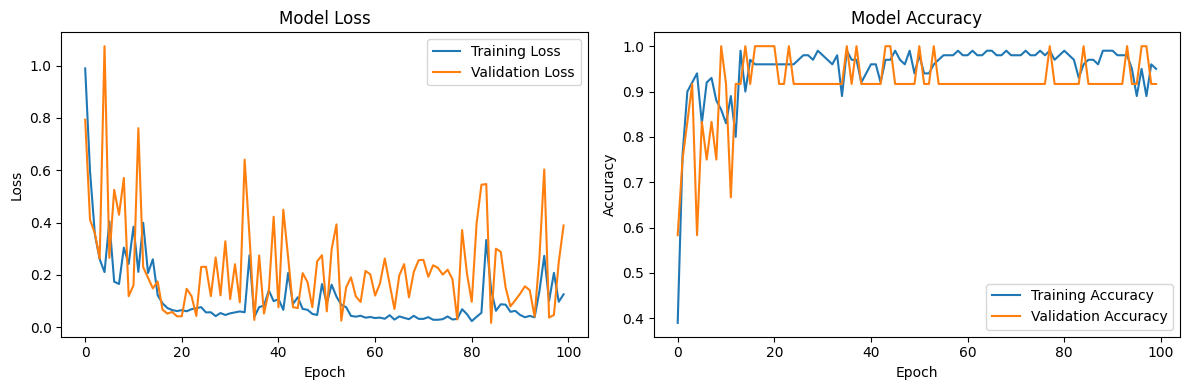

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Загрузка и подготовка данных
iris = load_iris()
X, y = iris['data'], iris['target']
X = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(X)
y = OneHotEncoder().fit_transform(y.reshape(-1, 1)).toarray()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Определение нейронной сети
def create_model(input_size=4, hidden_size=100, output_size=3):
    model = models.Sequential([
        layers.Dense(hidden_size, activation='relu', input_shape=(input_size,)),
        layers.Dense(hidden_size, activation='relu'),
        layers.Dense(hidden_size, activation='relu'),
        layers.Dense(output_size, activation='softmax')  # Используем softmax для классификации
    ])
    return model

# Создание модели
model = create_model()

# Компиляция модели
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Вывод структуры модели
model.summary()

# Создаем собственный callback для вывода результатов каждые 10 эпох
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:  # Выводим результаты каждые 10 эпох
            print(f'Epoch [{epoch+1}/100], Loss: {logs["loss"]:.4f}, '
                  f'Accuracy: {logs["accuracy"]:.4f}, '
                  f'Val Loss: {logs["val_loss"]:.4f}, '
                  f'Val Accuracy: {logs["val_accuracy"]:.4f}')

# Обучение модели
num_epochs = 100
batch_size = 32

history = model.fit(X_train, y_train,
                   epochs=num_epochs,
                   batch_size=batch_size,
                   validation_split=0.1,
                   callbacks=[CustomCallback()],  # Добавляем наш callback
                   verbose=0)  # Отключаем стандартный вывод

# Тестирование модели
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

# Пример предсказания для одного образца
sample = X_test[0].reshape(1, -1)  # Добавляем размерность батча
prediction = model.predict(sample, verbose=0)
print(f'\nSample prediction: {prediction[0]}')
print(f'Actual value: {y_test[0]}')

# Визуализация процесса обучения
plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# График точности
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Нужно улучшить:

 1. **Добавление ранней остановки (Early Stopping)**
   - **Проблема**: Модель обучается фиксированное количество эпох (100), что может привести к переобучению или избыточным вычислениям, если модель уже достигла оптимальной производительности.
   - **Улучшение**: Используйте `EarlyStopping` callback, чтобы остановить обучение, если метрика (например, `val_loss`) перестает улучшаться.
   - **Пример**:
     ```python
     early_stopping = tf.keras.callbacks.EarlyStopping(
         monitor='val_loss',  # Отслеживаем валидационную потерю
         patience=10,         # Количество эпох без улучшений, после которых обучение остановится
         restore_best_weights=True,  # Восстанавливаем лучшие веса модели
         verbose=1
     )

     history = model.fit(X_train, y_train,
                        epochs=num_epochs,
                        batch_size=batch_size,
                        validation_split=0.1,
                        callbacks=[CustomCallback(), early_stopping],  # Добавляем early stopping
                        verbose=0)
     ```

2. **Регуляризация для предотвращения переобучения**
   - **Проблема**: Модель может переобучаться, особенно если данные ограничены (как в случае с Iris dataset). У вас 3 скрытых слоя по 100 нейронов, что может быть избыточным для такого простого набора данных.
   - **Улучшение**: Добавьте регуляризацию (например, L2) или dropout, чтобы уменьшить переобучение.
   - **Пример**:
     ```python
     def create_model(input_size=4, hidden_size=100, output_size=3):
         model = models.Sequential([
             layers.Dense(hidden_size, activation='relu', input_shape=(input_size,),
                          kernel_regularizer=tf.keras.regularizers.l2(0.01)),  # L2 регуляризация
             layers.Dropout(0.3),  # Dropout для предотвращения переобучения
             layers.Dense(hidden_size, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.01)),
             layers.Dropout(0.3),
             layers.Dense(hidden_size, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.01)),
             layers.Dropout(0.3),
             layers.Dense(output_size, activation='softmax')
         ])
         return model
     ```

3. **Сохранение и загрузка модели**
   - **Проблема**: После обучения модель не сохраняется, что требует повторного обучения при каждом использовании.
   - **Улучшение**: Добавьте сохранение модели в файл и возможность ее загрузки для повторного использования.
   - **Пример**:
     ```python
     # Сохранение модели
     model.save('iris_model.h5')
     print("Модель сохранена в 'iris_model.h5'")

     # Загрузка модели (при необходимости)
     # loaded_model = tf.keras.models.load_model('iris_model.h5')
     ```



/home/tim/myenv/lib64/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 100)            │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,003 (82.04 KB)

 Trainable params: 21,003 (82.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch [10/100], Loss: 0.4140, Accuracy: 0.9400, Val Loss: 0.3672, Val Accuracy: 1.0000
Epoch [20/100], Loss: 0.3517, Accuracy: 0.8900, Val Loss: 0.4020, Val Accuracy: 0.8333
Epoch [30/100], Loss: 0.2998, Accuracy: 0.9500, Val Loss: 0.3028, Val Accuracy: 1.0000
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 21.


Модель сохранена в 'iris_model.h5'

Test Loss: 0.2925
Test Accuracy: 0.9474

Sample prediction: [1.1162651e-05 6.7981571e-02 9.3200731e-01]
Actual value: [0. 0. 1.]


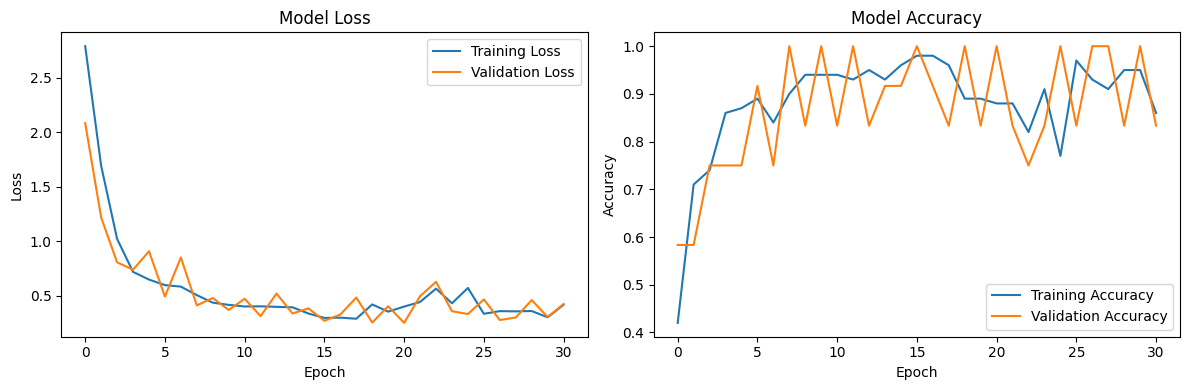

In [74]:
# code 8

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Загрузка и подготовка данных
iris = load_iris()
X, y = iris['data'], iris['target']
X = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(X)
y = OneHotEncoder().fit_transform(y.reshape(-1, 1)).toarray()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Определение нейронной сети
def create_model(input_size=4, hidden_size=100, output_size=3):

    model = models.Sequential([
             layers.Dense(hidden_size, activation='relu', input_shape=(input_size,),
                          kernel_regularizer=tf.keras.regularizers.l2(0.01)),  # L2 регуляризация
             layers.Dropout(0.1),  # Dropout для предотвращения переобучения
             layers.Dense(hidden_size, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.01)),
             layers.Dropout(0.1),
             layers.Dense(hidden_size, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.01)),
             layers.Dropout(0.1),
             layers.Dense(output_size, activation='softmax')
    ])
    return model

# Создание модели
model = create_model()

# Компиляция модели
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Вывод структуры модели
model.summary()

# Создаем собственный callback для вывода результатов каждые 10 эпох
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:  # Выводим результаты каждые 10 эпох
            print(f'Epoch [{epoch+1}/100], Loss: {logs["loss"]:.4f}, '
                  f'Accuracy: {logs["accuracy"]:.4f}, '
                  f'Val Loss: {logs["val_loss"]:.4f}, '
                  f'Val Accuracy: {logs["val_accuracy"]:.4f}')

# Обучение модели
num_epochs = 100
batch_size = 32

early_stopping = tf.keras.callbacks.EarlyStopping(
         monitor='val_loss',  # Отслеживаем валидационную потерю
         patience=10,         # Количество эпох без улучшений, после которых обучение остановится
         restore_best_weights=True,  # Восстанавливаем лучшие веса модели
         verbose=1
)

history = model.fit(X_train, y_train,
                   epochs=num_epochs,
                   batch_size=batch_size,
                   validation_split=0.1,
                   callbacks=[CustomCallback(), early_stopping],  # Добавляем наш callback
                   verbose=0)  # Отключаем стандартный вывод

# Сохранение модели
model.save('iris_model.h5')
print("Модель сохранена в 'iris_model.h5'")

# Загрузка модели (при необходимости)
# loaded_model = tf.keras.models.load_model('iris_model.h5')

# Тестирование модели
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

# Пример предсказания для одного образца
sample = X_test[0].reshape(1, -1)  # Добавляем размерность батча
prediction = model.predict(sample, verbose=0)
print(f'\nSample prediction: {prediction[0]}')
print(f'Actual value: {y_test[0]}')

# Визуализация процесса обучения
plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# График точности
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()